In [198]:

import pandas as pd
import glob
import os
import numpy as np
import cmocean as cm


In [27]:
# data = pd.read_csv('../data/LKF_RGPS/LKF_RGPS_w0001.txt', sep="\t", header=0)

path = "../data/LKF_RGPS/" # use your path
all_files = glob.glob(os.path.join(path , "LKF*.txt"))

li = []

for filename in all_files:
    df = pd.read_csv(filename, sep="\t", header=0)
    li.append(df)

frame = pd.concat(li, axis=0, ignore_index=True)

/var/folders/15/x70gn2y97r72ffx5ghvst8140000gq/T/ipykernel_52418/2215033416.py:9: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename, sep="\t", header=0)


In [44]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.path as mpath
import matplotlib.pyplot as plt

In [70]:
lon.min()

-180

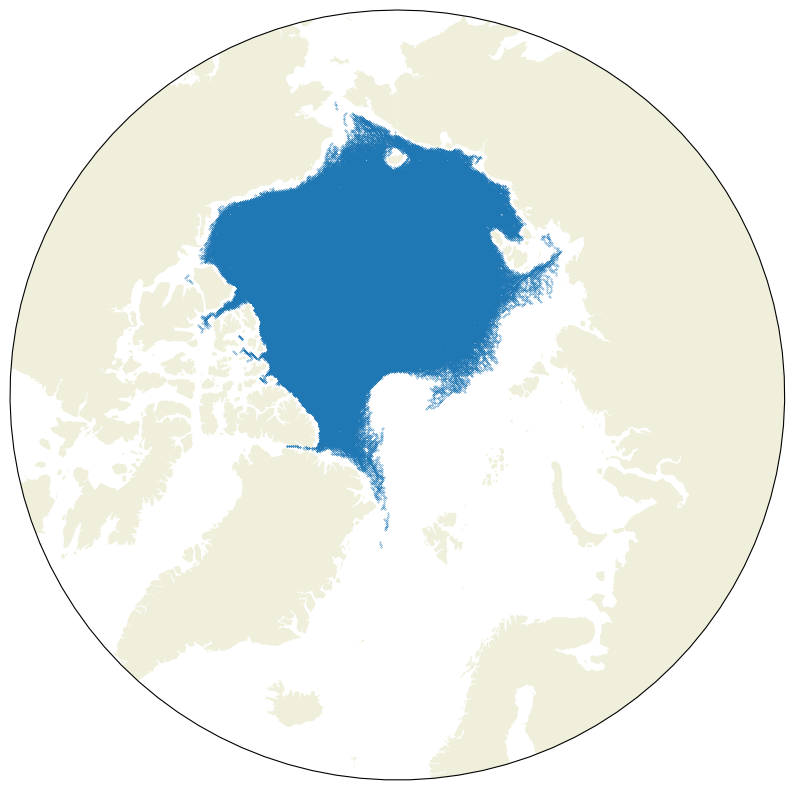

In [55]:
fig = plt.figure(figsize=[10, 10])
ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())

lon = frame.set_index('LKF_No.').lon
lat = frame.set_index('LKF_No.').lat

ax1.plot(lon,lat,markersize=0.5,marker='.',linestyle='',transform=ccrs.PlateCarree())

ax1.add_feature(cfeature.LAND)
ax1.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax1.set_boundary(circle, transform=ax1.transAxes)

In [71]:
def grid(lat_range,lon_range,delta):
    lat = np.arange(lat_range[0],lat_range[1]+delta,delta)
    lon = np.arange(lon_range[0],lon_range[1]+delta,delta) 
    return lat,lon

# def regrid

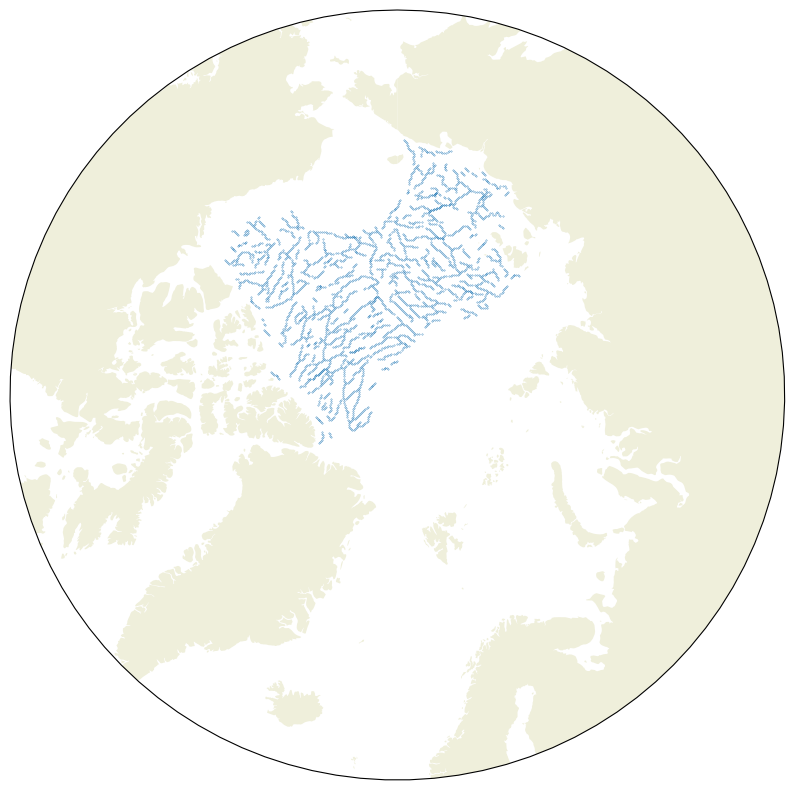

In [83]:
lkf_coords = frame[frame['Date(RGPS_format)']=="1997310_1997313"]

fig = plt.figure(figsize=[10, 10])
ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())

lon = lkf_coords.set_index('LKF_No.').lon
lat = lkf_coords.set_index('LKF_No.').lat

ax1.plot(lon,lat,markersize=0.5,marker='.',linestyle='',transform=ccrs.PlateCarree())

ax1.add_feature(cfeature.LAND)
ax1.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax1.set_boundary(circle, transform=ax1.transAxes)

In [182]:
lat,lon = grid([65,90],[-180,180],0.25)

In [191]:
len(frame['Date(RGPS_format)'].unique())*3

1953

In [192]:
lkf_coords = frame#[frame['Date(RGPS_format)']=="1997310_1997313"]

number_lkf = np.zeros((len(lon),len(lat)))

dims = number_lkf.shape

for iy  in range(dims[1]-1):
    for ix  in range(dims[0]-1):
        lat_coord = lat[iy]
        lon_coord = lon[ix]
        in_lon = np.bitwise_and(lkf_coords['lon'] >= lon[ix], lkf_coords['lon'] <= lon[ix+1])
        in_lat = np.bitwise_and(lkf_coords['lat'] >= lat[iy], lkf_coords['lat'] <= lat[iy+1])
        mask = np.bitwise_and(in_lon,in_lat)

        number_lkf[ix,iy] = np.sum(mask)
        # pass

number_lkf[number_lkf==0]=np.nan

In [193]:
np.nansum(number_lkf), lkf_coords.shape[0]

(1620605.0, 1620605)

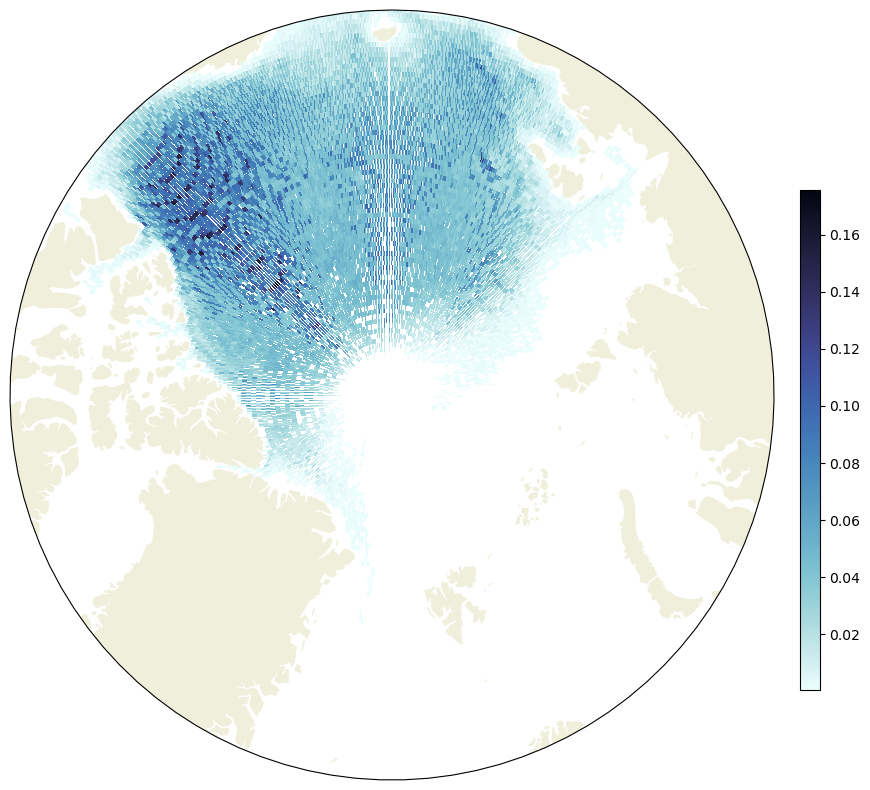

In [203]:
fig = plt.figure(figsize=[10, 10])
ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())

cbar = ax1.pcolormesh(lon, lat, number_lkf.T/1953, transform=ccrs.PlateCarree(),cmap=cm.cm.ice_r)

ax1.add_feature(cfeature.LAND)
ax1.set_extent([-180, 180, 70, 90], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax1.set_boundary(circle, transform=ax1.transAxes)

cax = fig.add_axes([0.92, 0.2, 0.02, 0.5])
cb=fig.colorbar(cbar, cax=cax, orientation='vertical')

plt.savefig('../manuscript/figures/LKF_from_RGPS.pdf',dpi=300)

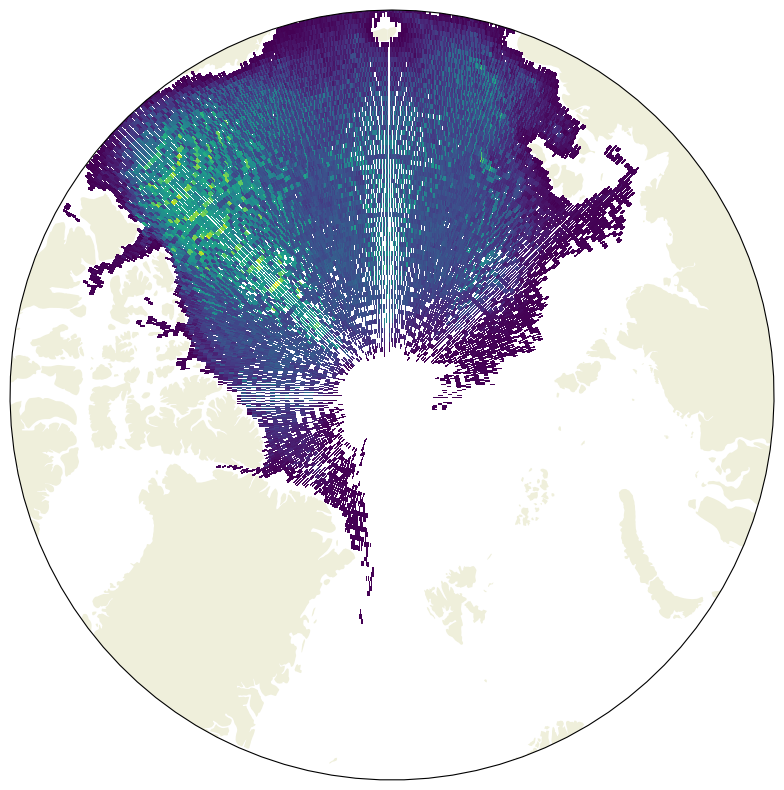

In [194]:
fig = plt.figure(figsize=[10, 10])
ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())

ax1.pcolormesh(lon, lat, number_lkf.T, transform=ccrs.PlateCarree())

ax1.add_feature(cfeature.LAND)
ax1.set_extent([-180, 180, 70, 90], ccrs.PlateCarree())

theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

ax1.set_boundary(circle, transform=ax1.transAxes)

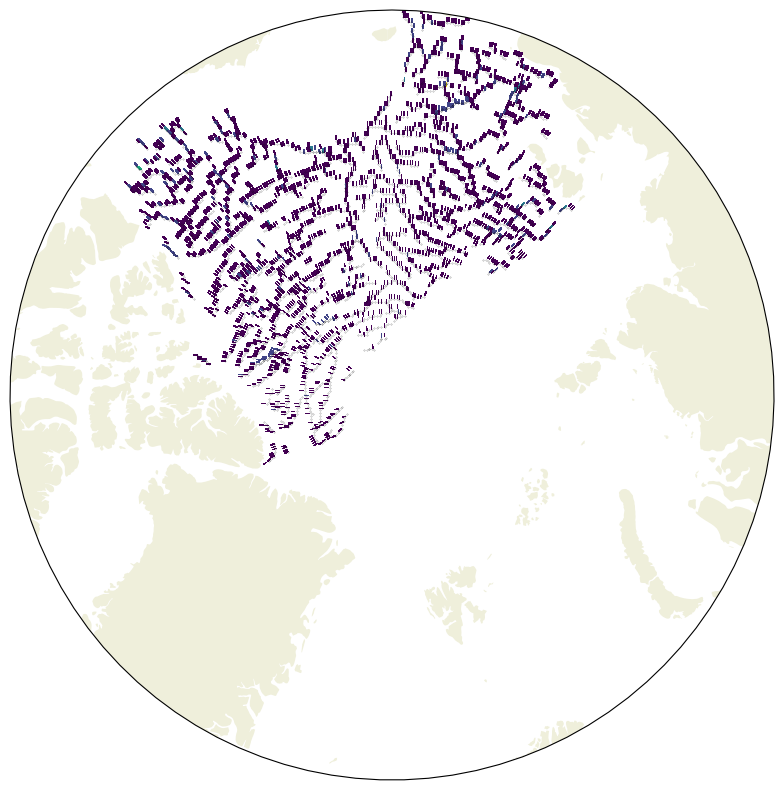

In [186]:
# lkf_coords = frame[frame['Date(RGPS_format)']=="1997310_1997313"]

# fig = plt.figure(figsize=[10, 10])
# ax1 = fig.add_subplot(1, 1, 1, projection=ccrs.NorthPolarStereo())

# lon_p = lkf_coords.set_index('LKF_No.').lon
# lat_p = lkf_coords.set_index('LKF_No.').lat

# ax1.plot(lon_p,lat_p,markersize=0.5,marker='.',linestyle='',transform=ccrs.PlateCarree(),color='k',alpha=0.5)

# ax1.pcolormesh(lon, lat, number_lkf.T, transform=ccrs.PlateCarree())


# ax1.add_feature(cfeature.LAND)
# ax1.set_extent([-180, 180, 70, 90], ccrs.PlateCarree())

# theta = np.linspace(0, 2*np.pi, 100)
# center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
# circle = mpath.Path(verts * radius + center)

# ax1.set_boundary(circle, transform=ax1.transAxes)